# Experiment: Cleaned iSTAGING Dataset EDA and Split Design

Objective:
- Inspect the structure of `datasets/cleaned_istaging.csv` and the MUSE ROI metadata.
- Verify that only atomic ROI features with IDs `<= 299` are retained for modeling.
- Reproduce the default split design used by the production preprocessing code.
- Verify the whole-study OOD holdout strategy and the REF/TAR cohort counts.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve().parent.parent if Path.cwd().name == 'jupyter-notebook' else Path.cwd().resolve()
RAW_DATASET = ROOT / 'datasets' / 'cleaned_istaging.csv'
MUSE_JSON = ROOT / 'datasets' / 'MUSE_ROI_complete_list.json'
PROCESSED_DIR = ROOT / 'artifacts' / 'data' / 'processed'

REF_MIN_AGE = 20
REF_MAX_AGE = 49
TAR_MIN_AGE = 50
TAR_MAX_AGE = 97
HOLDOUT_STUDY = 'HANDLS'

NORMAL_DIAGNOSES = {
    'CN',
    'CN assumed by study criteria',
    'Cognitively normal',
    'Cognitively Normal',
    'Cognitively Unimpaired',
    'Memory Complainer (Healthy control)',
    'Memory Complainer (Healthy control) MMSE < 28',
    'Non-Memory Complainer (Healthy control)',
    'Normal',
    'Normal Cognition',
}


## Load raw and processed artifacts

This cell inspects the raw CSV, the generated split manifest, and the ROI metadata exported by `prepare-data`.


In [2]:
raw = pd.read_csv(RAW_DATASET, low_memory=False)
manifest = json.loads((PROCESSED_DIR / 'split_manifest.json').read_text()) if (PROCESSED_DIR / 'split_manifest.json').exists() else None
roi_metadata = pd.read_csv(PROCESSED_DIR / 'roi_metadata.csv') if (PROCESSED_DIR / 'roi_metadata.csv').exists() else None

print(f'Rows: {len(raw):,}')
print(f'Columns: {len(raw.columns):,}')
display(raw[['PTID', 'Study', 'Age', 'Diagnosis']].head())

if manifest is not None:
    split_table = pd.DataFrame(manifest['splits']).T[['rows', 'subjects', 'eligible_rows', 'eligible_subjects']]
    display(split_table)

if roi_metadata is not None:
    print(f"Retained ROI features after excluding composite IDs > 299: {len(roi_metadata):,}")
    display(roi_metadata.head())


Rows: 37,740
Columns: 294


,PTID,Study,Age,Diagnosis
0,301D00252,ACCORD,56.800000,NaN
1,301D00252,ACCORD,59.923888,NaN
2,301D00262,ACCORD,68.100000,NaN
3,301D00262,ACCORD,71.319713,NaN
4,301D00262,ACCORD,75.664682,NaN


,rows,subjects,eligible_rows,eligible_subjects
application,233,233,226,226
id_test,3734,1823,3724,1823
ood_test,233,233,226,226
train,29428,14581,29350,14581
val,3695,1823,3688,1823


Retained ROI features after excluding composite IDs > 299: 145


,feature_name,roi_id,roi_name,roi_full_name,muse_roi_name,available
0,MUSE_Volume_122,122,Right FuG fusiform gyrus,Right Fusiform Gyrus,M0_fug_fusiform_gyrus_R,No
1,MUSE_Volume_105,105,Left AOrG anterior orbital gyrus,Left Anterior Orbital Gyrus,M0_aorg_anterior_orbital_gyrus_L,No
2,MUSE_Volume_87,87,temporal lobe WM right,Temporal Lobe White Matter Right,M0_temporal_Lobe_WM_R,No
3,MUSE_Volume_39,39,Left Cerebellum Exterior,Left Cerebellum Exterior,M0_cerebellum_exterior_L,No
4,MUSE_Volume_192,192,Right SMC supplementary motor cortex,Right Supplementary Motor Cortex,M0_smc_supplementary_motor_cortex_R,No


## Study distribution and whole-study OOD holdout

The implementation holds out `HANDLS` as the OOD/application study by default.


,study,rows
0,ADNI,9981
1,BLSA,4055
2,SHIP,3311
3,OASIS,2820
4,WHIMS,2141
5,AIBL,1676
6,GSP,1570
7,CARDIA,1379
8,ACCORD,1365
9,SPRINT,1332


HANDLS rows: 233
HANDLS unique subjects: 233


,PTID,Study,Age,Diagnosis
22199,8031226101,HANDLS,70.5,CN
22200,8031226102,HANDLS,65.6,CN
22201,8031310802,HANDLS,41.8,CN
22202,8031496301,HANDLS,71.7,CN
22203,8032682801,HANDLS,63.1,CN


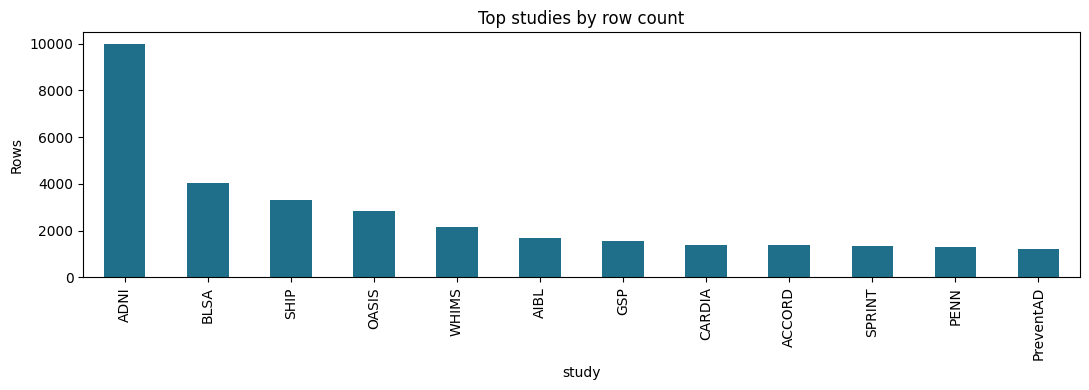

In [3]:
study_counts = raw['Study'].fillna('UNKNOWN').value_counts().rename_axis('study').reset_index(name='rows')
display(study_counts)

ax = study_counts.head(12).plot.bar(x='study', y='rows', figsize=(11, 4), color='#1f6f8b', legend=False)
ax.set_title('Top studies by row count')
ax.set_ylabel('Rows')
plt.tight_layout()

handls = raw.loc[raw['Study'] == HOLDOUT_STUDY, ['PTID', 'Study', 'Age', 'Diagnosis']].copy()
print(f'HANDLS rows: {len(handls):,}')
print(f"HANDLS unique subjects: {handls['PTID'].nunique():,}")
display(handls.head())


## Default REF/TAR cohort logic

REF: cognitively normal only, ages 20-49.
TAR: all subjects, ages 50-97.


In [4]:
eda = raw[['PTID', 'Study', 'Age', 'Diagnosis']].copy()
eda['Age'] = pd.to_numeric(eda['Age'], errors='coerce')
eda['Diagnosis'] = eda['Diagnosis'].fillna('')
eda['cohort_bucket'] = 'excluded'
eda.loc[eda['Diagnosis'].isin(NORMAL_DIAGNOSES) & eda['Age'].between(REF_MIN_AGE, REF_MAX_AGE), 'cohort_bucket'] = 'ref'
eda.loc[eda['Age'].between(TAR_MIN_AGE, TAR_MAX_AGE), 'cohort_bucket'] = 'tar'

display(eda['cohort_bucket'].value_counts(dropna=False).rename_axis('bucket').reset_index(name='rows'))
display(
    eda.groupby(['Study', 'cohort_bucket']).size().rename('rows').reset_index().sort_values(['rows'], ascending=False).head(20)
)


,bucket,rows
0,tar,32831
1,ref,4157
2,excluded,752


,Study,cohort_bucket,rows
2,ADNI,tar,9980
10,BLSA,tar,3831
25,OASIS,tar,2739
33,WHIMS,tar,2141
31,SHIP,tar,1910
5,AIBL,tar,1670
30,SHIP,ref,1401
0,ACCORD,tar,1365
32,SPRINT,tar,1332
28,PENN,tar,1273


## ROI metadata and atlas assets

The visualizer uses the MUSE ROI mapping plus the IXI atlas and segmentation in `datasets/`. Composite ROI IDs above 299 are intentionally excluded from model inputs even though they remain available in the full JSON mapping.


In [5]:
muse_map = json.loads(MUSE_JSON.read_text())
muse_preview = pd.DataFrame(muse_map).T.reset_index(drop=True)[['ID', 'Name', 'Full_Name', 'MUSE_ROI_Name', 'Available']]
display(muse_preview.head(12))

atlas_files = pd.DataFrame(
    [
        {'file': 'atlas.nii.gz', 'exists': (ROOT / 'datasets' / 'atlas.nii.gz').exists()},
        {'file': 'atlas_segmentation.nii.gz', 'exists': (ROOT / 'datasets' / 'atlas_segmentation.nii.gz').exists()},
        {'file': 'MUSE_ROI_complete_list.json', 'exists': MUSE_JSON.exists()},
    ]
)
display(atlas_files)


,ID,Name,Full_Name,MUSE_ROI_Name,Available
0,702,ICV,Intra Cranial Volume,M5_ICV,Yes
1,701,TOTALBRAIN,Total Brain Volume,M5_total_brain,Yes
2,600,CSF,Cerebrospinal Fluid,M4_cort_CSF,Yes
3,601,GM,Gray Matter,M4_GM,Yes
4,604,WM,White Matter,M4_WM,Yes
5,606,GM_L,Gray Matter Left,M4_GM_L,Yes
6,607,WM_L,White Matter Left,M4_WM_L,Yes
7,613,GM_R,Gray Matter Right,M4_GM_R,Yes
8,614,WM_R,White Matter Right,M4_WM_R,Yes
9,501,CORPUS_CALLOSUM,Corpus Callosum,M3_corpus_callosum,No


,file,exists
0,atlas.nii.gz,True
1,atlas_segmentation.nii.gz,True
2,MUSE_ROI_complete_list.json,True


## Next steps

- Use `python -m age_decoupled_surrealgan.cli prepare-data` to regenerate processed artifacts after any cohort-rule changes.
- Use the split manifest in `artifacts/data/processed/` as the source of truth for train/val/id-test/OOD/application partitions.
- Launch the API and GUI after training to inspect subject-level latents and atlas overlays.
